In [1]:
from load_data import load_raw_data
from clean_data import clean_data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns
import plotly.express as px
import plotly.io as pio

In [2]:
pio.templates['plotly'].layout['autosize'] = False

#### Reading and cleaning the dataset

In [3]:
dataset=load_raw_data()

In [4]:
df=clean_data(dataset)

In [5]:
df['SeniorCitizen']=df['SeniorCitizen'].map({0:'No',1:'Yes'})

In [6]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Evaluating number of services per customer

In [7]:
services=df[["PhoneService","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]]
services.head()

,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,No,DSL,No,Yes,No,No,No,No
1,Yes,DSL,Yes,No,Yes,No,No,No
2,Yes,DSL,Yes,Yes,No,No,No,No
3,No,DSL,Yes,No,Yes,Yes,No,No
4,Yes,Fiber optic,No,No,No,No,No,No


In [8]:
mapping={"Yes":1, "Fiber optic":1, "DSL":1, "No":0, "No internet service":0}

In [9]:
for col in services.columns:
    services.loc[:,col]=services.loc[:,col].map(mapping)

In [10]:
services.head()

,PhoneService,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,0,1,0,1,0,0,0,0
1,1,1,1,0,1,0,0,0
2,1,1,1,1,0,0,0,0
3,0,1,1,0,1,1,0,0
4,1,1,0,0,0,0,0,0


In [11]:
services.isna().sum()

PhoneService        0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

In [12]:
df_services=pd.concat((df,services.sum(axis=1).to_frame().rename(columns={0:"n_services"})),axis=1)
df_services.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,n_services
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,2
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,4
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,4
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,2


In [13]:
df_services[df_services["Churn"]=="No"].describe(include=['O'])

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,n_services
count,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163,5163
unique,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,1,8
top,Male,No,Yes,No,Yes,No,DSL,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,No,1
freq,2619,4497,2724,3390,4653,2536,1957,2036,1902,1883,2026,1889,1913,2220,2768,1296,5163,1452


#### Numeric features and number of services

In [14]:
df_numeric_services=df_services[["n_services","tenure","MonthlyCharges","TotalCharges", "Churn"]]
df_numeric_services.head()

,n_services,tenure,MonthlyCharges,TotalCharges,Churn
0,2,1,29.85,29.85,No
1,4,34,56.95,1889.50,No
2,4,2,53.85,108.15,Yes
3,4,45,42.30,1840.75,No
4,2,2,70.70,151.65,Yes


In [15]:
gb_df_numeric_services=df_services.groupby(by=["n_services","Churn"])[["tenure","MonthlyCharges","TotalCharges"]].mean().reset_index()
gb_df_numeric_services.head()

,n_services,Churn,tenure,MonthlyCharges,TotalCharges
0,1,No,31.861570,21.251653,692.854408
1,1,Yes,7.182432,21.424662,154.524324
2,2,No,15.377841,54.793892,851.449858
3,2,Yes,6.874667,61.045200,421.929333
4,3,No,23.369449,61.171847,1425.161901


In [16]:
# Average monthly charges per number of services

In [17]:
fig = px.bar(gb_df_numeric_services, x="n_services", y="MonthlyCharges",color="Churn", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

In [18]:
# Average total charges per number of services

In [19]:
fig = px.bar(gb_df_numeric_services, x="n_services", y="TotalCharges",color="Churn", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

In [20]:
# Average tenure per number of services

In [21]:
fig = px.bar(gb_df_numeric_services, x="n_services", y="tenure",color="Churn", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

#### Summary:
- The average monthly charge of churned customers is always higher than that of the non churned customers when looking in term of number of services.

- The opposite happens for total charges and tenure in term of number of services.

#### Churn counts per number of services

In [22]:
group=df_services.groupby(by=["Churn","n_services"]).size().reset_index(name="count")
group.head()

,Churn,n_services,count
0,No,1,1452
1,No,2,352
2,No,3,563
3,No,4,680
4,No,5,771


In [23]:
total_counts={}
for val in group["n_services"].unique():
    total_counts[val]=group[group["n_services"]==val]["count"].sum()

In [24]:
for i in range(len(group)):
    group.loc[i,"percent_text"]=str(round(100*group.loc[i,"count"]/total_counts[group["n_services"][i]],1))+"%"
    group.loc[i,"%"]=100*group.loc[i,"count"]/total_counts[group["n_services"][i]]

In [25]:
# Churn rate as a function of number of subscribed services.

In [26]:
# y-axis : counts. The below percent visualization maybe better due to the percent values show on top of the bars, but this counts representantion shows how the customers are distributed along the number of services categories.
fig = px.bar(group, x="n_services", y="count",color="Churn", text="percent_text", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(textposition='outside')
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

In [27]:
# y-axis : percent. This representation causes less awkwardness due to the percents, but does not offer info on the number of customers per number of services.
fig = px.bar(group, x="n_services", y="%",color="Churn", text="percent_text", category_orders={"Churn":["Yes","No"]}, barmode="group")
fig.update_traces(textposition='outside')
fig.update_traces(marker_color="rgba(99, 110, 250, 0.65)", marker_line_color="rgb(99, 110, 250)",marker_line_width=2, selector=dict(name='No'))
fig.update_traces(marker_color="rgba(239, 85, 59, 0.65)", marker_line_color="rgb(239, 85, 59)",marker_line_width=2, selector=dict(name='Yes'))
fig.show()

In [28]:
# There is a small difference between this analysis and the previous one, where we examined the higher churn rate among customers with both phone and internet services. In the previous analysis, 
# customers with internet service could also subscribe to additional internet-related services (e.g., online security, streaming TV, or tech support). Here, however, the first two bins refer exclusively
# to customers subscribed to a single service.

In [29]:
# other option to obtain the same results
pd.crosstab(df_services["Churn"],df_services["n_services"],normalize='columns')*100

n_services,1,2,3,4,5,6,7,8
Churn,,,,,,,,
No,90.75,48.418157,56.526104,65.321806,72.735849,77.939394,87.40458,94.208494
Yes,9.25,51.581843,43.473896,34.678194,27.264151,22.060606,12.59542,5.791506


#### Summary:
- Customers with only 1 service or with 8 services have less than 10% chance of churn. It is, however, worth to note that the last two bins account for only 259 customers (3.7% of the customer population)

- The higher churn rates happen for clients with 2, 3 or 4 services. Let's take a look at this subgroups

#### Risk analysis: customers with 2, 3 or 4 subscribed services

In [30]:
df_service_risk=df_services[df_services["n_services"].isin([2,3,4])]

In [31]:
len(df_service_risk)

2764

In [32]:
df_service_risk["Churn"].value_counts(normalize=True)*100

Churn
No     57.706223
Yes    42.293777
Name: proportion, dtype: float64

In [33]:
print(f"Percentage of total customers: {len(df_service_risk)/len(df)*100:.2f}%")

Percentage of total customers: 39.31%


In [34]:
print(f"Percentage of total lost revenue: {df_service_risk[df_service_risk["Churn"]=="Yes"]["MonthlyCharges"].sum()/df[df["Churn"]=="Yes"]["MonthlyCharges"].sum() *100:.2f}%")

Percentage of total lost revenue: 59.69%


In [35]:
print(f"Percentage of total churners: {len(df_service_risk[df_service_risk["Churn"]=="Yes"])/len(df[df["Churn"]=="Yes"])*100:.2f}%")

Percentage of total churners: 62.55%


#### Summary:
- Customers with only 2, 3 or 4 services sum up to 39.3% of total customers. Of those, 42.3% churn.

- The churners from this group represent 62.5% of total churners

- These 62.5% churners are responsible for 59.7% lost revenue

#### Comparing across each categorical feature

In [36]:
categorical_features=[col for col in df.columns if df[col].dtype=='object']

In [37]:
categorical_features

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [38]:
# To enable direct comparisons of category proportions, we exclude the options listed below. 
# Customers in the potential high-risk group are subscribed to at least two services, so the "No internet service" category is not 
# applicable to this group and would always have zero observations.

exclude = {
    "InternetService": "No",
    "OnlineSecurity": "No internet service",
    "OnlineBackup": "No internet service",
    "DeviceProtection": "No internet service",
    "TechSupport": "No internet service",
    "StreamingTV": "No internet service",
    "StreamingMovies": "No internet service",
}

for col in categorical_features:
    if col in exclude:
        value=exclude[col]
        df_trimmed=df[df[col]!=value]
        df_risk_trimmed=df_service_risk[df_service_risk[col]!=value]
    else:
        df_trimmed=df
        df_risk_trimmed=df_service_risk

    comparison=pd.concat((df_trimmed[col].value_counts(normalize=True),df_risk_trimmed[col].value_counts(normalize=True)),axis=1, keys=["All customers", "High-risk customers"])*100
    display(comparison)

,All customers,High-risk customers
gender,,
Male,50.469283,50.542692
Female,49.530717,49.457308


,All customers,High-risk customers
SeniorCitizen,,
No,83.759954,79.160637
Yes,16.240046,20.839363


,All customers,High-risk customers
Partner,,
No,51.749147,63.965268
Yes,48.250853,36.034732


,All customers,High-risk customers
Dependents,,
No,70.150739,78.97974
Yes,29.849261,21.02026


,All customers,High-risk customers
PhoneService,,
Yes,90.32992,85.166425
No,9.67008,14.833575


...

,All customers,High-risk customers
StreamingMovies,,
No,50.453556,75.470333
Yes,49.546444,24.529667


,All customers,High-risk customers
Contract,,
Month-to-month,55.105233,84.153401
Two year,23.961889,4.305355
One year,20.932878,11.541245


,All customers,High-risk customers
PaperlessBilling,,
Yes,59.2719,67.149059
No,40.7281,32.850941


,All customers,High-risk customers
PaymentMethod,,
Electronic check,33.631968,48.046310
Mailed check,22.810011,19.573082
Bank transfer (automatic),21.928328,16.389291
Credit card (automatic),21.629693,15.991317


,All customers,High-risk customers
Churn,,
No,73.421502,57.706223
Yes,26.578498,42.293777


##### Tenure, Monthly Charges, Total Charges

In [39]:
df.describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [40]:
df_service_risk.describe()

,tenure,MonthlyCharges,TotalCharges
count,2764.000000,2764.000000,2764.000000
mean,19.864689,66.428944,1327.746997
std,19.308114,18.268332,1390.598392
min,1.000000,28.450000,29.150000
25%,3.000000,50.250000,220.725000
50%,13.000000,70.300000,839.175000
75%,31.000000,81.212500,2023.937500
max,72.000000,97.650000,6588.950000


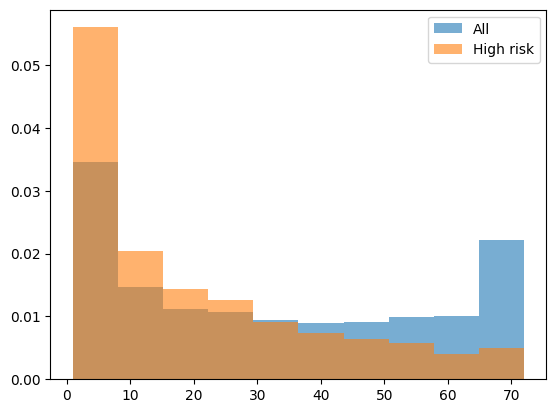

In [41]:
plt.hist(df["tenure"],density=True,alpha=0.6,label="All")
plt.hist(df_service_risk["tenure"],density=True,alpha=0.6,label="High risk")
plt.legend();

#### Summary: 
Possible risk group with 42.3% churn: customers with 2, 3 or 4 services, formed of 2764 customers (39.3% of total customers).

Compared with the overall customer population, this subgroup presents the following characteristics:

- No significant differences in the proportion of male/female

- Higher proportion of senior citizens in this group: 20.8% compared with 16.2% in the overall population

- Lower proportion of customers with partners in this group: 36% compared with 48.3% in the overall population

- Lower proportion of customers with dependents in this group: 21% compared with 29.8% in the overall population

- Lower proportion of customers with phone service in this group: 85.2% compared with 90.3% in the overall population

- Lower proportion of customers with multiple lines: 36.4% compared with 42.2% in the overall population

- The customer have roughly the same proportion of fiber optic and DSL internet: 55.3%/44.7% compared with 56%/44% in the overall population

- Lower proportion of customers with online security: 19.8% compared with 36.6% in the overall population

- Lower proportion of customers with online backup: 23.1% compared with 44% in the overall population

- Lower proportion of customers with device protection: 18.4% compared with 43.9% in the overall population

- Lower proportion of customers with tech support: 15.7% compared with 37% in the overall population

- Lower proportion of customers with streaming TV: 24.6% compared with 49% in the overall population

- Lower proportion of customers with streaming Movies: 24.5% compared with 49.5% in the overall population

- Higher proportion of month to month contracts and lower of 1y and 2y, (m-m/1y/2y): 84.2%/11.5%/4.3% against 55%/21%/24% in the overall population

- Higher proportion of paperless billing: 67% compared with 59% in the overall population

- Shorter tenure average(median) 19.9(13) months compared with 32.4(29) months in the overall population

- Similar monthly charges average(median) \\$66.4(\\$70.3) compared with \\$64.8(\\$70.35) in the overall population

- Lower total charges average(median) \\$1327.75(\\$839.17) compared with \\$2283.3(\\$1397.5) in the overall population

- Electronic check payments grow, while the remainder payment methods reduce, they are 48% (Electronic check) against 33.6% (Electronic check) in the overall population.
19.6% (Mailed check) 16.4% (Bank transfer (automatic)) and 16% (Credit card (automatic)) compared with 22.8% (Mailed check), 21.9% (Bank transfer (automatic)) and 21.6% (Credit card (automatic)) in the overall population

- The customers from this group churn more: 42.3% compared with 26.6% in the overall population

#### Intersection of risk groups (Phone Service + Internet Service + 2,3 or 4 subscribed services)

In [42]:
df_service_risk[(df_service_risk["PhoneService"]=="Yes") & (df_service_risk["InternetService"]!="No")]["Churn"].value_counts(normalize=True)*100

Churn
No     55.31011
Yes    44.68989
Name: proportion, dtype: float64

In [43]:
print(f"Percentage of total customers: {len(df_service_risk[(df_service_risk["PhoneService"]=="Yes") & (df_service_risk["InternetService"]!="No")]["Churn"])/len(df)*100:.2f}%")

Percentage of total customers: 33.48%


#### Summary:
The intersection of the two risk groups (Phone Service + Internet Service + 2,3 or 4 subscribed services) represents 33.5% of the total customers and in this group 44.7% customers churn. 

#### Intersection of risk groups (Phone Service + Internet Service + 2,3 or 4 subscribed services + low tenure (customers level 0 and 1))

In [44]:
df_triple_risk=df_service_risk[(df_service_risk["PhoneService"]=="Yes") & (df_service_risk["InternetService"]!="No") & (df_service_risk["tenure"]<24)] # Risk 1, 2 and 3 intersection

In [45]:
df_triple_risk["Churn"].value_counts(normalize=True)*100

Churn
Yes    53.750775
No     46.249225
Name: proportion, dtype: float64

In [46]:
print(f"Percentage of total customers: {len(df_triple_risk["Churn"])/len(df)*100:.2f}%")

Percentage of total customers: 22.94%


In [47]:
print(f"Percentage of total churners: {len(df_triple_risk[df_triple_risk["Churn"]=="Yes"])/len(df[df["Churn"]=="Yes"])*100:.2f}%")

Percentage of total churners: 46.39%


In [48]:
print(f"Percentage of lost revenue in this group: {(df_triple_risk[df_triple_risk["Churn"]=="Yes"]["MonthlyCharges"].sum())/(df[df["Churn"]=="Yes"]["MonthlyCharges"].sum())*100:.2f}%")

Percentage of lost revenue in this group: 45.59%


#### Summary:
- The intersection of the three risk groups comprises 23% of the total customers. In this group, the churn rate is 54%.

- The churners in this group represent 46.4% of the total churners

- This 46.4% of total churners, are responsible for 45.6% of this month lost revenue